In [3]:
import torch
import numpy as np
import os

from diffusion import immap2p5, immap2
from training.common import load_model
from datasets.fastmri.common import load_knee_data
from models import NormUnet
from operators import Mask, Sense, FFT2D, Identity
from physics.mask import make_acc_mask
from visualization.image import plot_image
from physics.nle import whiten_from_kspace

/home/ee2178/scratch/ee2178/miniconda3/envs/env/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/scratch/ee2178/miniconda3/envs/env/lib/python3.9/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [4]:
os.chdir('/scratch/ee2178/ImMAP')

In [5]:
# GPU Settings
device = 'cuda'
# DiffLPDSNet Checkpoint
difflpdsnet_path = '/home/ee2178/scratch/ee2178/ImMAP/trained_nets/knee/LPDS_JDR_R6_polynomialsteps_RHO_Range/config.json'
denoiser_path = '/home/ee2178/scratch/ee2178/ImMAP/trained_nets/knee/LPDS_Denoiser/config.json'

In [6]:
net = load_model(difflpdsnet_path, device=device)
denoiser = load_model(denoiser_path, device=device)
# net.eval()

Power method returns L = (3346.33984375+3.0380237149074674e-05j)


In [7]:
fname = 'file1000052.h5'
kspace, smaps, knee_mask, gnd_truth = load_knee_data(kspace_fname = fname, slice_idx=15, device=device)

Loading slice 15 from /home/ee2178/scratch/ee2178/datasets/fastmri/knee/multicoil_val/file1000052.h5


In [8]:
# Mask generation
mask = make_acc_mask(shape=kspace[0,0].shape, accel = 6, acs_lines=20, device = device)

In [9]:
# Try whitening first
kspace_w, image_w, smaps_w, sigma_n, smaps_w, Zinv = whiten_from_kspace(kspace, smaps, mask = mask, R = 6, gnd_truth_kspace = kspace)

In [10]:
# Construct operator
E = Mask(mask) @ FFT2D() @ Sense(smaps_w)

In [11]:
# Constructing measurement/simulated kspace
meas_kspace = mask*kspace_w
sim_kspace = E(E.H(kspace))

In [12]:
sigma_y = sigma_n
save_dir = None

In [30]:
E = Mask(mask) @ FFT2D() @ Sense(smaps)
recon = immap2(meas_kspace, sigma_y, denoiser, E,    # Require usual inputs (measurent, nle, net, measurement op)
             lam = 8.0, 
             sigma_max = 1.0,             
             sigma_min=0.01,
             # Base Diffusion Hyperparameters
             beta = 0.05,    # Noise injection ratio, should belong in [0, 1]
             h_0 = 0.01,      # Initial step size
             save_dir = None,           
             verbose = True, 
             )

Iteration 1 complete. Noise level: 0.9977497458457947. p_t: 0.0006228907150216401 Tolerance Reached: True
Iteration 2 complete. Noise level: 0.9972352385520935. p_t: 0.0006232128362171352 Tolerance Reached: True
Iteration 3 complete. Noise level: 0.9966810345649719. p_t: 0.0006235604523681104 Tolerance Reached: True
Iteration 4 complete. Noise level: 0.9952458739280701. p_t: 0.0006244632531888783 Tolerance Reached: True
Iteration 5 complete. Noise level: 0.9929854869842529. p_t: 0.0006258931243792176 Tolerance Reached: True
Iteration 6 complete. Noise level: 0.9908174276351929. p_t: 0.0006272739265114069 Tolerance Reached: True
Iteration 7 complete. Noise level: 0.9872751832008362. p_t: 0.0006295493221841753 Tolerance Reached: True
Iteration 8 complete. Noise level: 0.9842125773429871. p_t: 0.0006315364735201001 Tolerance Reached: True
Iteration 9 complete. Noise level: 0.9802908897399902. p_t: 0.0006341082626022398 Tolerance Reached: True
Iteration 10 complete. Noise level: 0.97634166

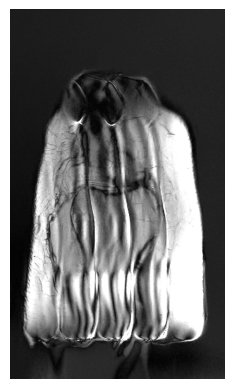

In [31]:
plot_image(recon, contrast=True)

In [13]:
# Experiment 1: Fixed D operator
from operators.ssdumask import SSDUMask
# ---------------------------------------------------------
# SSDU Masking Params
# ---------------------------------------------------------
ssdu_masking=True
ssdu_base_accel=1
ssdu_acs=10
ssdu_rho=(0.2, 0.2)
acs_lines = 20
D = SSDUMask(ssdu_base_accel, ssdu_acs, ssdu_rho, acs_lines, device = device) @ FFT2D() @ Sense(torch.ones_like(gnd_truth))

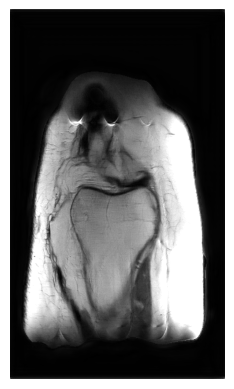

In [14]:
# e2e recon net warm start
e2e_path = '/home/ee2178/scratch/ee2178/ImMAP/trained_nets/knee/LPDS_MRI_Recon_R6/config.json'
e2e_net = load_model(e2e_path, device=device)
e2e_recon, _ = e2e_net(meas_kspace, E=E, sigma=sigma_y)
plot_image(e2e_recon, contrast=True)

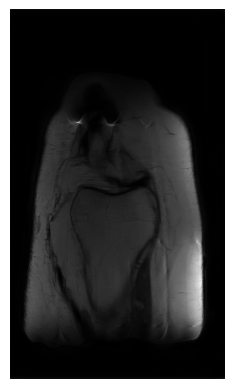

In [16]:
e2e_recon, _ = e2e_net(meas_kspace, E=E, sigma=sigma_y)
plot_image(e2e_recon)

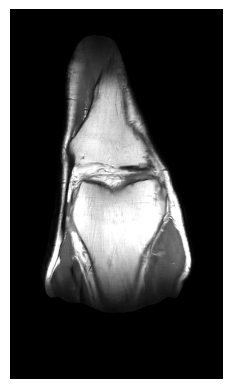

1.000125765800476


In [23]:
# Try just one run of difflpdsnet
sigma_t = torch.tensor([1.0], device = device)
ws = e2e_recon+sigma_t*torch.randn_like(E.H(meas_kspace))
with torch.no_grad():
    v, _ = net(
        meas_kspace, 
        E = E, 
        E_z = D,
        sigma = sigma_y,
        x_init=ws,
        sigma_t=sigma_t,
    )
    organ_mask = torch.ones_like(ws[0,0]) == 1
    nle = torch.sqrt(torch.sum(((ws-v)*organ_mask).abs()**2)/torch.sum(organ_mask))
plot_image(v*Zinv, contrast=True, thresh=1.0)
print(nle.item())

In [30]:
recon = immap2p5(meas_kspace, sigma_y, net, E,    # Require usual inputs (measurent, nle, net, measurement op)
             sigma_max = 1.0,             
             sigma_min=0.05,
             D = Identity() @ Identity(),            # Optional SSDU Operator for Image Domain masking
             organ_mask = None,         # Optional Organ Mask
             ws = e2e_recon, 
             # Base Diffusion Hyperparameters
             beta = 0.05,    # Noise injection ratio, should belong in [0, 1]
             h_0 = 0.01,      # Initial step size
             save_dir = None,           
             verbose = True, 
             )

Iteration 1 complete. Noise level: 1.0016889572143555.
Iteration 2 complete. Noise level: 1.0012028217315674.
Iteration 3 complete. Noise level: 1.0000393390655518.
Iteration 4 complete. Noise level: 0.9986174702644348.
Iteration 5 complete. Noise level: 0.9964045882225037.
Iteration 6 complete. Noise level: 0.9936311841011047.
Iteration 7 complete. Noise level: 0.9912405014038086.
Iteration 8 complete. Noise level: 0.9875211119651794.
Iteration 9 complete. Noise level: 0.9841582775115967.
Iteration 10 complete. Noise level: 0.9807249307632446.
Iteration 11 complete. Noise level: 0.9758429527282715.
Iteration 12 complete. Noise level: 0.9704628586769104.
Iteration 13 complete. Noise level: 0.9656054973602295.
Iteration 14 complete. Noise level: 0.9595428109169006.
Iteration 15 complete. Noise level: 0.9539424180984497.
Iteration 16 complete. Noise level: 0.9482675194740295.
Iteration 17 complete. Noise level: 0.9415330290794373.
Iteration 18 complete. Noise level: 0.9347338676452637.
I

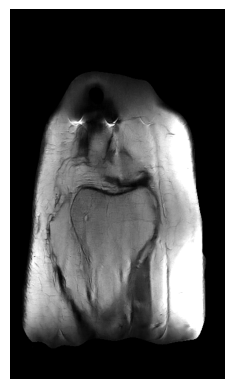

In [31]:
plot_image(
    recon*Zinv,
    contrast=True,
    thresh=1.0
)

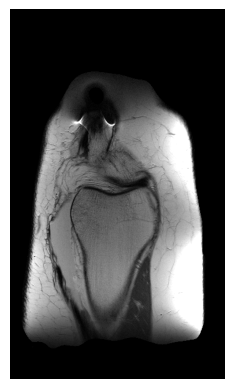

In [23]:
plot_image(
    gnd_truth,
    contrast=True,
    thresh=1.0
)